In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Đọc file dữ liệu đầu vào
# Bạn lưu ý đổi đường dẫn file cho đúng với thư mục máy của bạn nhé
df = pd.read_csv('processed_dulieuxettuyendaihoc.csv')

# Cấu hình hiển thị tiếng Việt không bị lỗi font trên đồ thị (nếu máy có cài font)
plt.rcParams['font.family'] = 'DejaVu Sans' # Hoặc 'Arial' tùy máy
plt.rcParams['axes.unicode_minus'] = False

In [24]:
print("--- PHẦN 1: THỐNG KÊ DỮ LIỆU ---")

# 1. Sắp xếp dữ liệu điểm DH1 theo thứ tự tăng dần
df_dh1_asc = df.sort_values(by='DH1', ascending=True)
print("\n1. Top 5 dòng đầu sau khi sắp xếp tăng dần theo DH1:")
print(df_dh1_asc[['DH1']].head())

# 2. Sắp xếp dữ liệu điểm DH2 tăng dần theo nhóm giới tính
df_dh2_gt = df.sort_values(by=['GT', 'DH2'], ascending=[True, True])
print("\n2. Top 5 dòng đầu sau khi sắp xếp tăng dần theo GT và DH2:")
print(df_dh2_gt[['GT', 'DH2']].head())

# Định nghĩa các hàm tính Tứ phân vị để dùng cho Pivot-table
def q1(x): return x.quantile(0.25)
def q2(x): return x.quantile(0.50)
def q3(x): return x.quantile(0.75)

agg_funcs = ['count', 'sum', 'mean', 'median', 'min', 'max', 'std', q1, q2, q3]
rename_cols = {'q1': 'Q1', 'q2': 'Q2', 'q3': 'Q3'}

# 3. Pivot-table thống kê DH1 theo KT
pivot_kt = df.pivot_table(values='DH1', index='KT', aggfunc=agg_funcs).rename(columns=rename_cols)
print("\n3. Pivot-table theo KT:\n", pivot_kt)

# 4. Pivot-table thống kê DH1 theo KT và KV
pivot_kt_kv = df.pivot_table(values='DH1', index=['KT', 'KV'], aggfunc=agg_funcs).rename(columns=rename_cols)
print("\n4. Pivot-table theo KT và KV:\n", pivot_kt_kv)

# 5. Pivot-table thống kê DH1 theo KT, KV và DT
pivot_kt_kv_dt = df.pivot_table(values='DH1', index=['KT', 'KV', 'DT'], aggfunc=agg_funcs).rename(columns=rename_cols)
print("\n5. Pivot-table theo KT, KV và DT:\n", pivot_kt_kv_dt)

--- PHẦN 1: THỐNG KÊ DỮ LIỆU ---

1. Top 5 dòng đầu sau khi sắp xếp tăng dần theo DH1:
     DH1
53  1.00
43  1.25
72  1.50
5   1.50
87  1.75

2. Top 5 dòng đầu sau khi sắp xếp tăng dần theo GT và DH2:
   GT   DH2
95  F  1.50
25  F  2.00
24  F  2.25
46  F  2.25
13  F  2.75

3. Pivot-table theo KT:
    count     sum      mean median   min   max       std      Q1    Q2     Q3
     DH1     DH1       DH1    DH1   DH1   DH1       DH1     DH1   DH1    DH1
KT                                                                          
A     49  163.50  3.336735   3.25  1.00  6.50  1.274296  2.2500  3.25  4.250
A1     6   17.50  2.916667   3.00  2.00  4.25  0.861201  2.1875  3.00  3.250
B      9   29.50  3.277778   3.50  1.75  4.50  0.823905  3.2500  3.50  3.750
C     14   79.25  5.660714   5.25  4.75  7.00  0.812209  5.0625  5.25  6.375
D1    22   84.25  3.829545   3.75  1.25  6.75  1.370146  3.0000  3.75  4.875

4. Pivot-table theo KT và KV:
        count    sum      mean median   min   max     


--- PHẦN 2: TRÌNH BÀY DỮ LIỆU ---

1. Bảng thống kê biến GT:
     Tần số  Tần suất (%)
GT                      
M       52          52.0
F       48          48.0


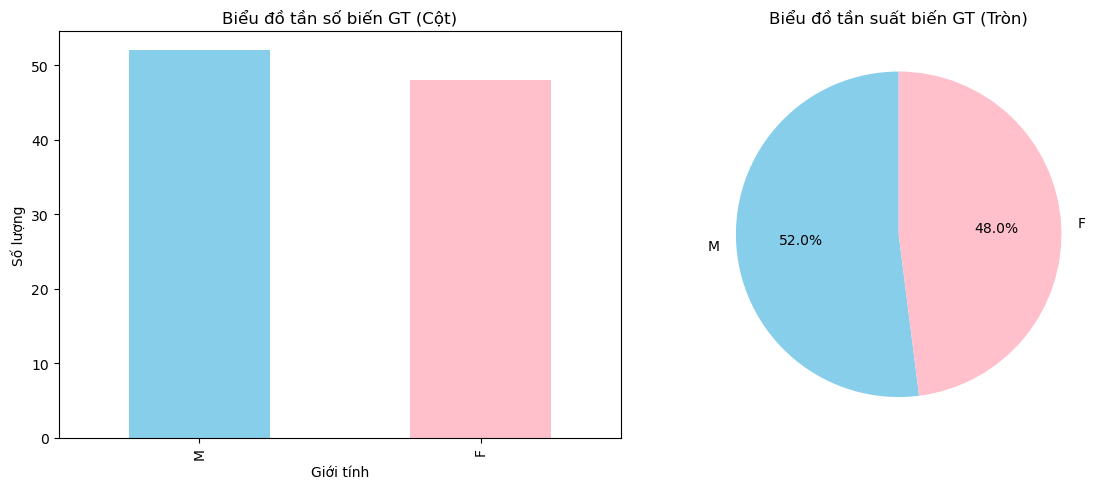


2. Thống kê mô tả US_TBM1, US_TBM2, US_TBM3:
           US_TBM1     US_TBM2    US_TBM3
count  100.000000  100.000000  100.00000
mean     2.434480    2.559600    2.67176
std      0.391203    0.377656    0.29981
min      1.616000    1.768000    1.91600
25%      2.107000    2.223000    2.47300
50%      2.480000    2.588000    2.70600
75%      2.724000    2.893000    2.87400
max      3.232000    3.416000    3.31600


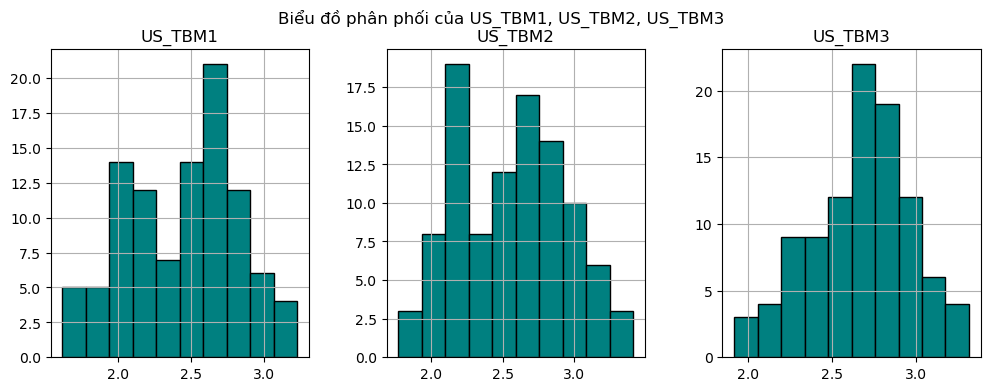


3. Tần số biến DT của học sinh NAM:
 DT
0.0    50
1.0     1
6.0     1
Name: count, dtype: int64

4. Tần số biến KV của học sinh nam, Kinh và thỏa điều kiện điểm:
 Series([], Name: count, dtype: int64)

5. Thống kê mô tả điểm của học sinh thỏa điều kiện câu 5:
         DH1   DH2  DH3
count  1.00  1.00  1.0
mean   6.75  5.25  5.0
std     NaN   NaN  NaN
min    6.75  5.25  5.0
25%    6.75  5.25  5.0
50%    6.75  5.25  5.0
75%    6.75  5.25  5.0
max    6.75  5.25  5.0


In [25]:
print("\n--- PHẦN 2: TRÌNH BÀY DỮ LIỆU ---")

# 1. Trình bày dữ liệu biến: GT
tan_so_gt = df['GT'].value_counts()
tan_xuat_gt = df['GT'].value_counts(normalize=True) * 100
bang_gt = pd.DataFrame({'Tần số': tan_so_gt, 'Tần suất (%)': tan_xuat_gt})
print("\n1. Bảng thống kê biến GT:\n", bang_gt)

# Vẽ biểu đồ biến GT
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tan_so_gt.plot(kind='bar', ax=axes[0], color=['skyblue', 'pink'])
axes[0].set_title('Biểu đồ tần số biến GT (Cột)')
axes[0].set_xlabel('Giới tính')
axes[0].set_ylabel('Số lượng')

tan_xuat_gt.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['skyblue', 'pink'], startangle=90)
axes[1].set_title('Biểu đồ tần suất biến GT (Tròn)')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

# 2. Trình bày dữ liệu lần lượt các biến: US_TBM1, US_TBM2 và US_TBM3
print("\n2. Thống kê mô tả US_TBM1, US_TBM2, US_TBM3:\n", df[['US_TBM1', 'US_TBM2', 'US_TBM3']].describe())
df[['US_TBM1', 'US_TBM2', 'US_TBM3']].hist(bins=10, figsize=(12, 4), layout=(1, 3), color='teal', edgecolor='black')
plt.suptitle('Biểu đồ phân phối của US_TBM1, US_TBM2, US_TBM3')
plt.show()

# 3. Trình bày dữ liệu biến DT với các học sinh là nam (giả định ký hiệu nam là 'M')
df_nam = df[df['GT'] == 'M']
print("\n3. Tần số biến DT của học sinh NAM:\n", df_nam['DT'].value_counts())

# 4. Học sinh nam thuộc dân tộc Kinh (giả định mã là 1), điểm thỏa điều kiện
# Lưu ý: Bạn hãy check lại trong file csv xem dân tộc Kinh ký hiệu là số 1 hay chữ "Kinh" để sửa cho đúng nhé
df_cond4 = df[(df['GT'] == 'M') & (df['DT'] == 1) & (df['DH1'] >= 5.0) & (df['DH2'] >= 4.0) & (df['DH3'] >= 4.0)]
print("\n4. Tần số biến KV của học sinh nam, Kinh và thỏa điều kiện điểm:\n", df_cond4['KV'].value_counts())

# 5. Lần lượt các biến DH1, DH2, DH3 >= 5.0 và thuộc khu vực 2NT
df_cond5 = df[(df['DH1'] >= 5.0) & (df['DH2'] >= 5.0) & (df['DH3'] >= 5.0) & (df['KV'] == '2NT')]
print("\n5. Thống kê mô tả điểm của học sinh thỏa điều kiện câu 5:\n", df_cond5[['DH1', 'DH2', 'DH3']].describe())


--- PHẦN 3: TRỰC QUAN HÓA THEO NHÓM PHÂN LOẠI ---


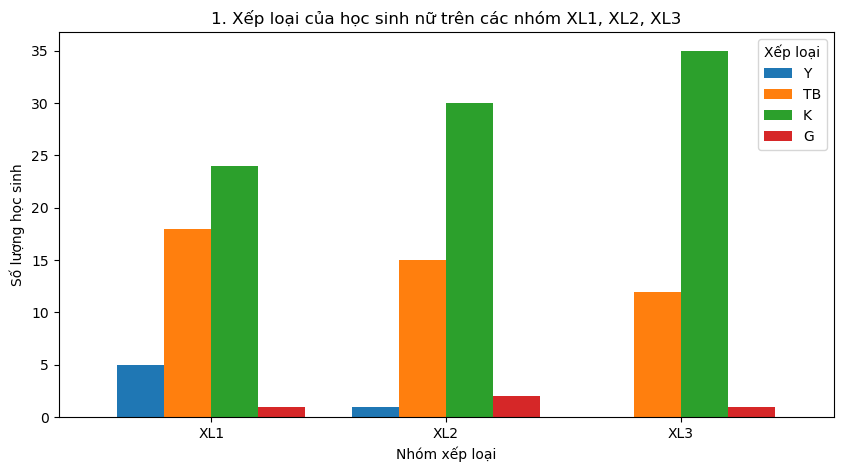

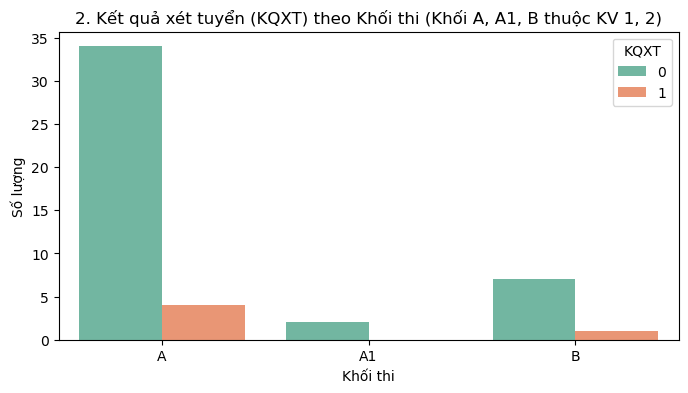

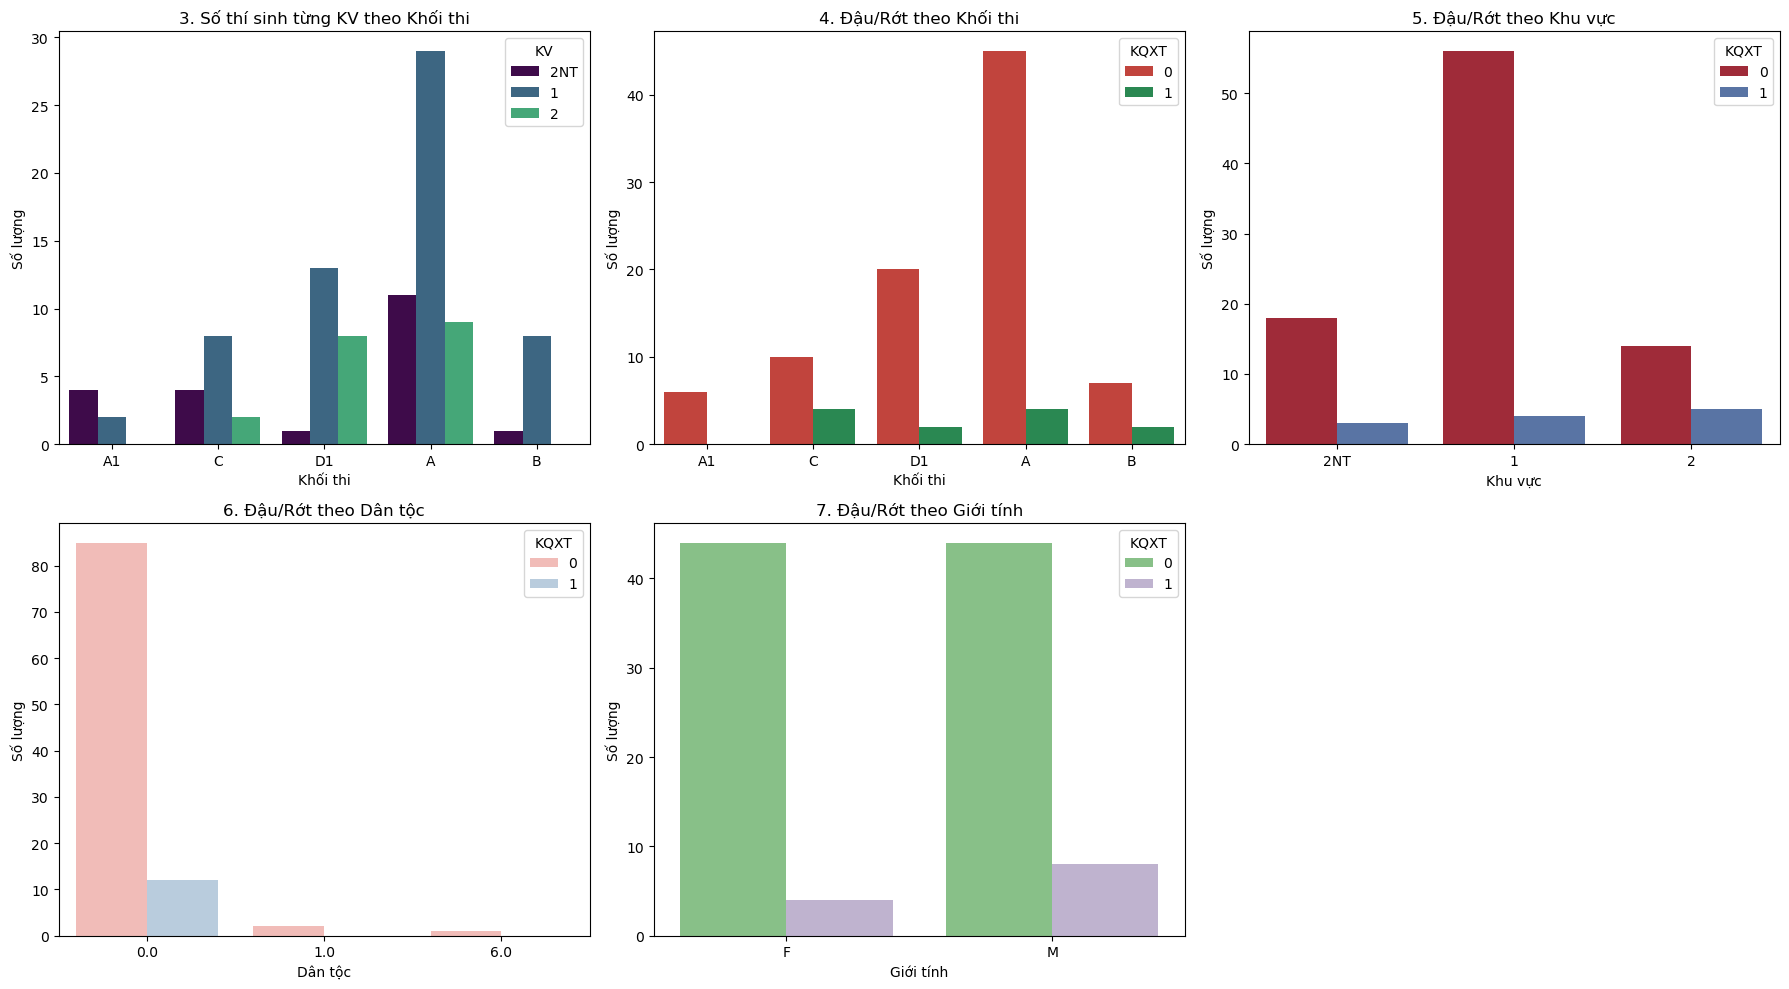

In [30]:
import warnings # Thêm thư viện này để tắt cảnh báo
print("\n--- PHẦN 3: TRỰC QUAN HÓA THEO NHÓM PHÂN LOẠI ---")

# TẮT TẤT CẢ CẢNH BÁO NHẮC NHỞ CỦA SEABORN/MATPLOTLIB
warnings.filterwarnings("ignore", category=UserWarning)

# Chuẩn hóa dữ liệu cột KV và DT về dạng chuỗi để tránh lệch kiểu dữ liệu
df['KV_str'] = df['KV'].astype(str)
df['DT_str'] = df['DT'].astype(str)

# Tự định nghĩa các bảng màu cố định bằng mã HEX
colors_set2 = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
colors_viridis = ['#440154', '#31688e', '#35b779', '#fde725']
colors_rdylgn = ['#d73027', '#1a9850', '#fee08b']
colors_coolwarm = ['#b2182b', '#4d70b0']
colors_pastel1 = ['#fbb4ae', '#b3cde3', '#ccebc5', '#decbe4']
colors_accent = ['#7fc97f', '#beaed4', '#fdc086']

# =============================================================================
# 1. Trực quan dữ liệu học sinh nữ trên các nhóm XL1, XL2, XL3 dạng unstacked
# =============================================================================
df_nu = df[df['GT'] == 'F'] 
df_nu_melt = df_nu.melt(value_vars=['XL1', 'XL2', 'XL3'], var_name='Nhom_XL', value_name='XepLoai')
df_nu_pivot = df_nu_melt.groupby(['Nhom_XL', 'XepLoai']).size().unstack(fill_value=0)

order_xl = [xl for xl in ['Y', 'TB', 'K', 'G', 'XS'] if xl in df_nu_pivot.columns]
df_nu_pivot = df_nu_pivot[order_xl]

df_nu_pivot.plot(kind='bar', figsize=(10, 5), width=0.8)
plt.title('1. Xếp loại của học sinh nữ trên các nhóm XL1, XL2, XL3')
plt.xlabel('Nhóm xếp loại')
plt.ylabel('Số lượng học sinh')
plt.xticks(rotation=0)
plt.legend(title='Xếp loại')
plt.show()


# =============================================================================
# 2. Trực quan dữ liệu KQXT trên nhóm học sinh khối A, A1, B thuộc khu vực 1, 2
# =============================================================================
df_filtered2 = df[df['KT'].isin(['A', 'A1', 'B']) & df['KV_str'].isin(['1', '2'])]

plt.figure(figsize=(8, 4))
sns.countplot(data=df_filtered2, x='KT', hue='KQXT', palette=colors_set2) 
plt.title('2. Kết quả xét tuyển (KQXT) theo Khối thi (Khối A, A1, B thuộc KV 1, 2)')
plt.xlabel('Khối thi')
plt.ylabel('Số lượng')
plt.show()


# =============================================================================
# TỪ CÂU 3 ĐẾN CÂU 7: GOM NHÓM VẼ CHUNG TRÊN LƯỚI ĐỒ THỊ (SUBPLOTS)
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 3. Số lượng thí sinh từng khu vực dựa trên từng nhóm khối thi
sns.countplot(data=df, x='KT', hue='KV', ax=axes[0, 0], palette=colors_viridis)
axes[0, 0].set_title('3. Số thí sinh từng KV theo Khối thi')
axes[0, 0].set_xlabel('Khối thi')
axes[0, 0].set_ylabel('Số lượng')

# 4. Số lượng thí sinh đậu, rớt trên từng nhóm khối thi
sns.countplot(data=df, x='KT', hue='KQXT', ax=axes[0, 1], palette=colors_rdylgn)
axes[0, 1].set_title('4. Đậu/Rớt theo Khối thi')
axes[0, 1].set_xlabel('Khối thi')
axes[0, 1].set_ylabel('Số lượng')

# 5. Số lượng thí sinh đậu rớt trên từng nhóm khu vực
sns.countplot(data=df, x='KV', hue='KQXT', ax=axes[0, 2], palette=colors_coolwarm)
axes[0, 2].set_title('5. Đậu/Rớt theo Khu vực')
axes[0, 2].set_xlabel('Khu vực')
axes[0, 2].set_ylabel('Số lượng')

# 6. Số lượng thí sinh đậu rớt dựa trên từng nhóm dân tộc
sns.countplot(data=df, x='DT_str', hue='KQXT', ax=axes[1, 0], palette=colors_pastel1)
axes[1, 0].set_title('6. Đậu/Rớt theo Dân tộc')
axes[1, 0].set_xlabel('Dân tộc')
axes[1, 0].set_ylabel('Số lượng')

# 7. Số lượng thí sinh đậu rớt dựa trên từng nhóm giới tính
sns.countplot(data=df, x='GT', hue='KQXT', ax=axes[1, 1], palette=colors_accent)
axes[1, 1].set_title('7. Đậu/Rớt theo Giới tính')
axes[1, 1].set_xlabel('Giới tính')
axes[1, 1].set_ylabel('Số lượng')

# Ẩn ô biểu đồ trống thừa (ô hàng 2, cột 3)
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()


--- PHẦN 4: TRỰC QUAN HÓA DỮ LIỆU NÂNG CAO ---


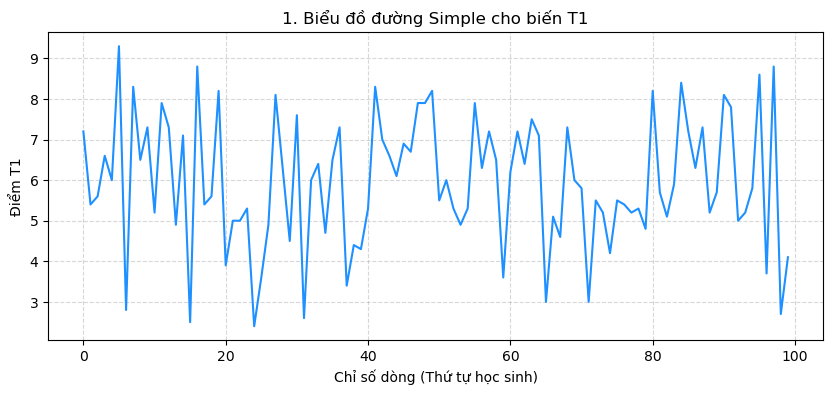


3. Bảng tần số cho biến phanlopt1:
phanlopt1
tb    46
k     23
kh    19
g     12
Name: count, dtype: int64


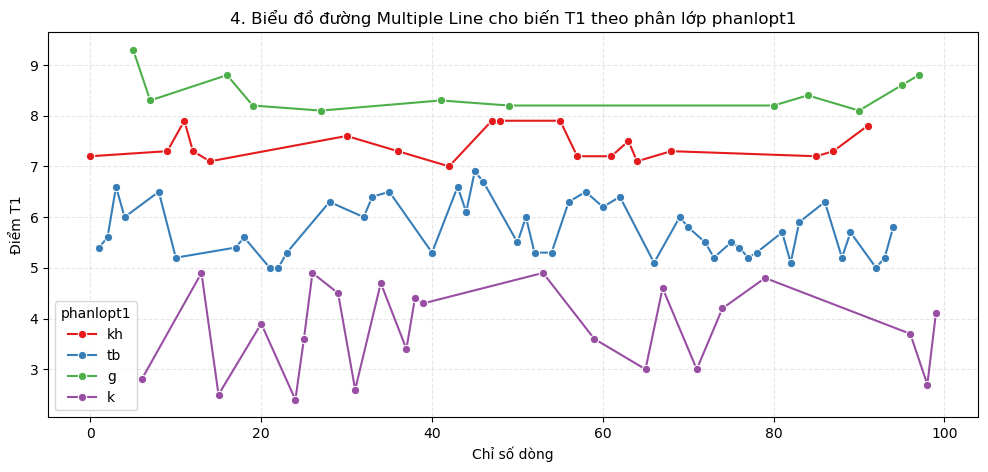

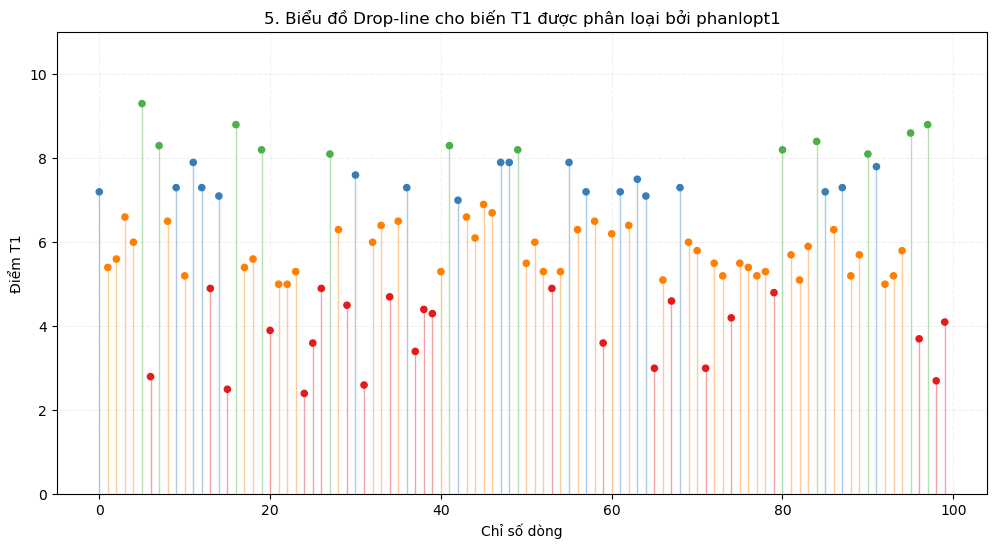

In [31]:
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("\n--- PHẦN 4: TRỰC QUAN HÓA DỮ LIỆU NÂNG CAO ---")
# Tắt các cảnh báo nhắc nhở để giao diện hiển thị sạch sẽ
warnings.filterwarnings("ignore", category=UserWarning)

# 1. Vẽ biểu đồ đường Simple cho biến T1
plt.figure(figsize=(10, 4))
plt.plot(df.index, df['T1'], color='dodgerblue', linewidth=1.5)
plt.title('1. Biểu đồ đường Simple cho biến T1')
plt.xlabel('Chỉ số dòng (Thứ tự học sinh)')
plt.ylabel('Điểm T1')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 2. Tạo biến phân loại (phanlopt1) cho môn toán (T1) theo yêu cầu đề bài
def xep_loai_t1(score):
    if score < 5: 
        return 'k'   # kém
    elif score < 7: 
        return 'tb'  # trung bình
    elif score < 8: 
        return 'kh'  # khá (đổi thành 'kh' để không bị trùng ký hiệu 'k' của kém)
    else: 
        return 'g'   # giỏi

df['phanlopt1'] = df['T1'].apply(xep_loai_t1)

# 3. Lập bảng tần số cho biến phanlopt1
print("\n3. Bảng tần số cho biến phanlopt1:")
print(df['phanlopt1'].value_counts())

# 4. Vẽ biểu đồ đường Multiple Line cho biến T1 được phân loại bởi biến phanlopt1
plt.figure(figsize=(12, 5))
df_sorted_idx = df.sort_index()
# Định nghĩa bộ màu HEX cố định cho 4 nhóm (Kém: Đỏ, TB: Cam, Khá: Xanh dương, Giỏi: Xanh lá)
colors_p4 = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

sns.lineplot(data=df_sorted_idx, x=df_sorted_idx.index, y='T1', hue='phanlopt1', marker='o', palette=colors_p4)
plt.title('4. Biểu đồ đường Multiple Line cho biến T1 theo phân lớp phanlopt1')
plt.xlabel('Chỉ số dòng')
plt.ylabel('Điểm T1')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# 5. Vẽ biểu đồ Drop-line cho biến T1 được phân loại bởi biến phanlopt1
plt.figure(figsize=(12, 6))
colors_dict = {'k': '#e41a1c', 'tb': '#ff7f00', 'kh': '#377eb8', 'g': '#4daf4a'}

# Vẽ các đường thẳng đứng thả từ điểm dữ liệu xuống trục hoành y=0
plt.vlines(x=df.index, ymin=0, ymax=df['T1'], colors=df['phanlopt1'].map(colors_dict), alpha=0.4, linewidth=1)
# Chấm các điểm tròn ở đỉnh đầu mỗi đường thả
plt.scatter(df.index, df['T1'], c=df['phanlopt1'].map(colors_dict), s=20, zorder=3)

plt.title('5. Biểu đồ Drop-line cho biến T1 được phân loại bởi phanlopt1')
plt.xlabel('Chỉ số dòng')
plt.ylabel('Điểm T1')
plt.ylim(0, 11)
plt.grid(True, linestyle='--', alpha=0.2)
plt.show()


--- PHẦN 5: MÔ TẢ DỮ LIỆU VÀ KHẢO SÁT DẠNG PHÂN PHỐI ---

1. Thống kê mô tả chi tiết của biến Toán T1:
 count    100.000000
mean       5.946000
std        1.608338
min        2.400000
25%        5.000000
50%        5.850000
75%        7.200000
max        9.300000
Name: T1, dtype: float64
-> Độ lệch (Skewness) của T1: -0.1782
-> Độ nhọn (Kurtosis) của T1: -0.4801


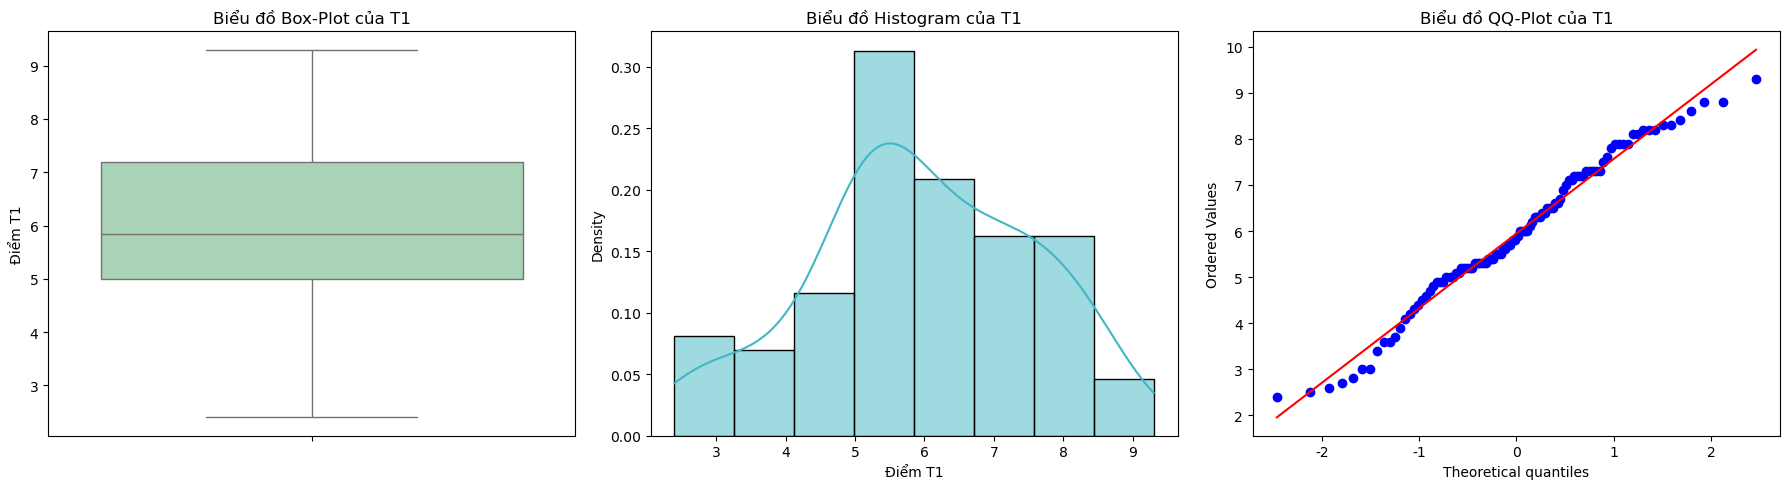


2. Đang tiến hành khảo sát phân phối T1 theo từng phân nhóm học lực...


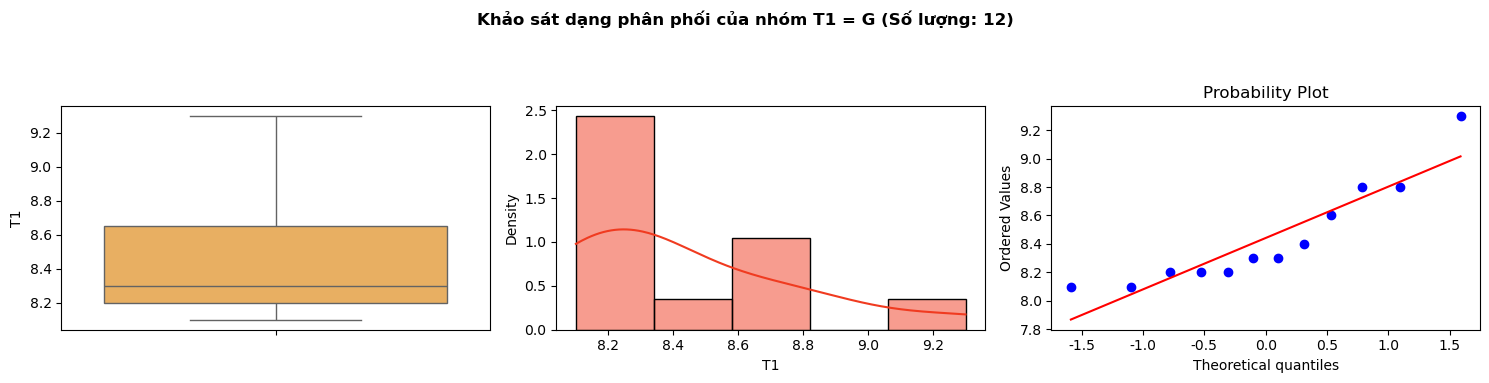

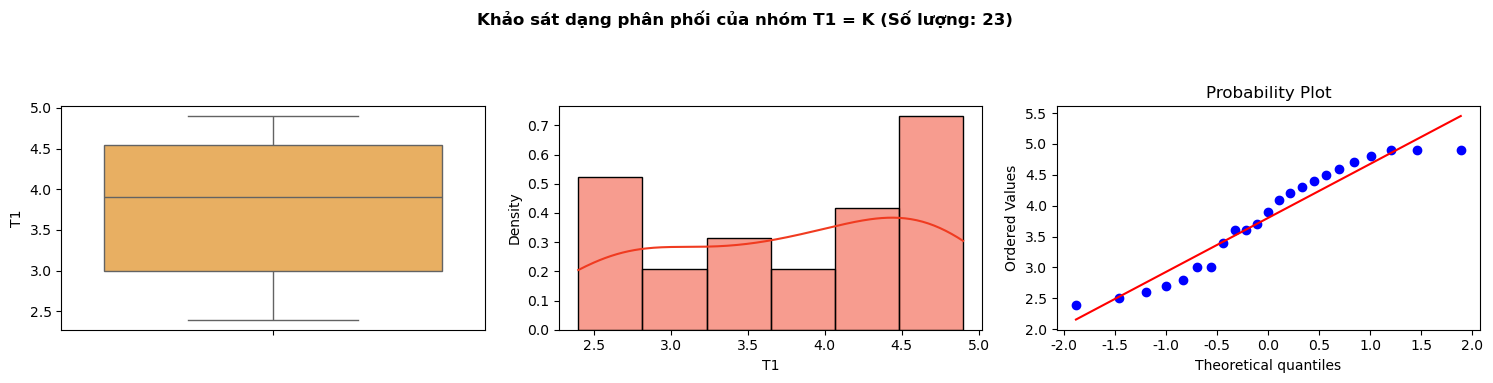

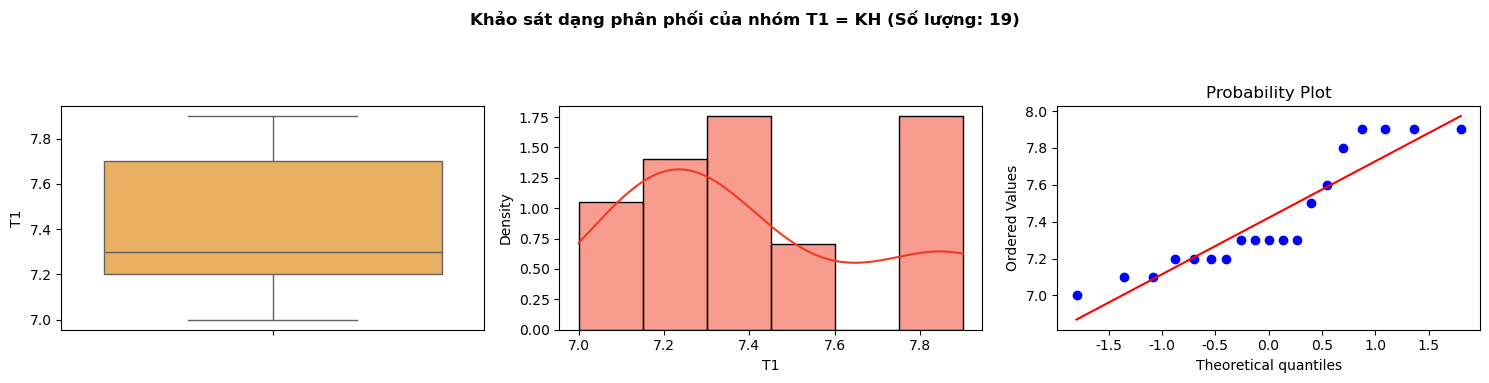

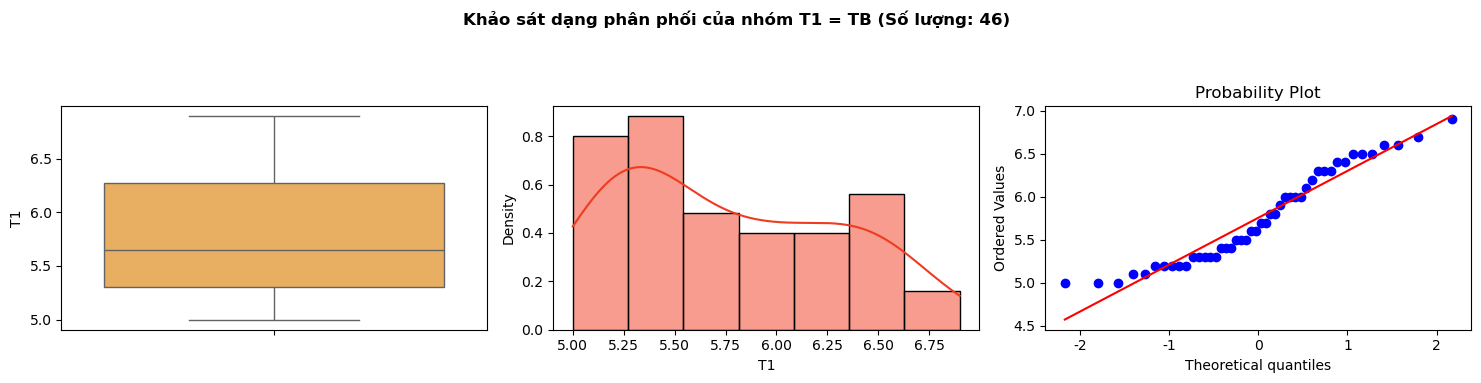


3. Kết quả khảo sát tương quan giữa T1 và DH1:
-> Hiệp phương sai (Covariance): 0.1128
-> Hệ số tương quan Pearson (Correlation): 0.0493


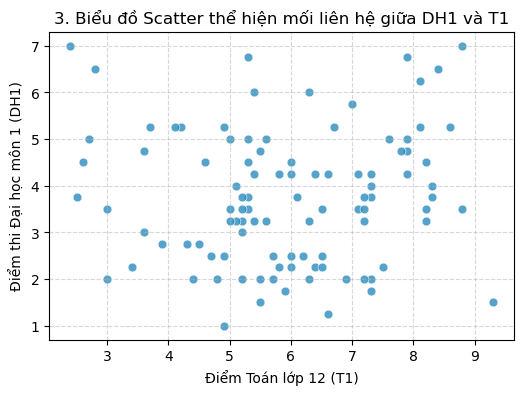


4. Đang trực quan đồ thị tương quan T1 & DH1 phân rã theo Khu vực...


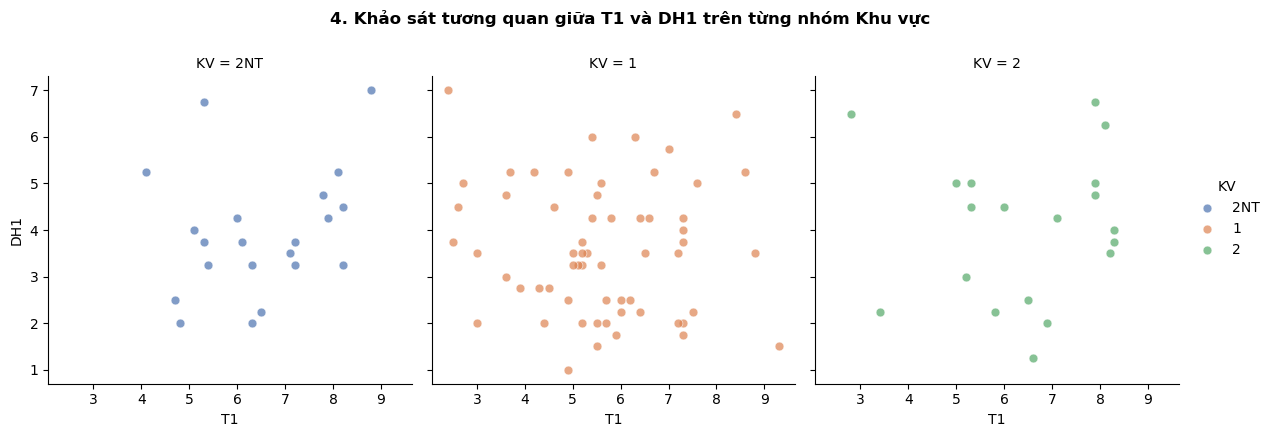


5. Ma trận hiệp phương sai (Covariance Matrix) giữa DH1, DH2, DH3:
           DH1       DH2       DH3
DH1  2.028939  0.053081  0.027778
DH2  0.053081  1.123712 -0.101010
DH3  0.027778 -0.101010  1.083965

   Ma trận tương quan (Correlation Matrix) giữa DH1, DH2, DH3:
           DH1       DH2       DH3
DH1  1.000000  0.035154  0.018731
DH2  0.035154  1.000000 -0.091523
DH3  0.018731 -0.091523  1.000000

-> Đang xuất biểu đồ Scatter Matrix đôi một...


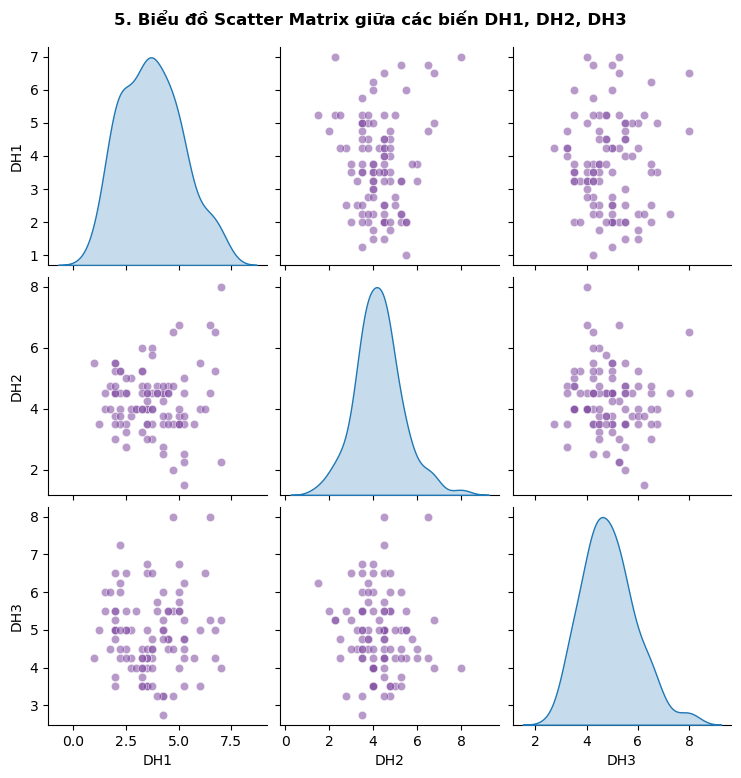

In [32]:
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

print("\n--- PHẦN 5: MÔ TẢ DỮ LIỆU VÀ KHẢO SÁT DẠNG PHÂN PHỐI ---")

# 1. Hãy mô tả và khảo sát phân phối cho biến T1
print("\n1. Thống kê mô tả chi tiết của biến Toán T1:\n", df['T1'].describe())
print(f"-> Độ lệch (Skewness) của T1: {df['T1'].skew():.4f}")
print(f"-> Độ nhọn (Kurtosis) của T1: {df['T1'].kurt():.4f}")

# Vẽ bộ 3 biểu đồ khảo sát phân phối cho T1
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Box-Plot
sns.boxplot(y=df['T1'], ax=axes[0], color='#a1dab4')
axes[0].set_title('Biểu đồ Box-Plot của T1')
axes[0].set_ylabel('Điểm T1')

# Histogram kèm đường mật độ KDE
sns.histplot(df['T1'], kde=True, ax=axes[1], color='#41b6c4', stat="density")
axes[1].set_title('Biểu đồ Histogram của T1')
axes[1].set_xlabel('Điểm T1')

# QQ-Plot kiểm chứng phân phối chuẩn
stats.probplot(df['T1'], dist="norm", plot=axes[2])
axes[2].set_title('Biểu đồ QQ-Plot của T1')

plt.tight_layout()
plt.show()


# 2. Hãy mô tả và khảo sát phân phối cho biến T1 trên từng nhóm phân lớp (phanlopT1)
print("\n2. Đang tiến hành khảo sát phân phối T1 theo từng phân nhóm học lực...")
for nhom, sub_df in df.groupby('phanlopt1'):
    # Chỉ khảo sát nếu nhóm có dữ liệu
    if len(sub_df) > 0:
        fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
        fig.suptitle(f'Khảo sát dạng phân phối của nhóm T1 = {nhom.upper()} (Số lượng: {len(sub_df)})', y=1.08, fontweight='bold')
        
        sns.boxplot(y=sub_df['T1'], ax=axes[0], color='#feb24c')
        sns.histplot(sub_df['T1'], kde=True, ax=axes[1], color='#f03b20', stat="density")
        
        # Điều kiện để vẽ đường chuẩn QQ-plot là số lượng mẫu phải > 2
        if len(sub_df) > 2:
            stats.probplot(sub_df['T1'], dist="norm", plot=axes[2])
        else:
            axes[2].set_title("Không đủ số mẫu để chạy QQ-Plot")
            
        plt.tight_layout()
        plt.show()


# 3. Hãy khảo sát tương quan giữa biến DH1 theo biến T1
covariance_t1_dh1 = df['T1'].cov(df['DH1'])
correlation_t1_dh1 = df['T1'].corr(df['DH1'])
print(f"\n3. Kết quả khảo sát tương quan giữa T1 và DH1:")
print(f"-> Hiệp phương sai (Covariance): {covariance_t1_dh1:.4f}")
print(f"-> Hệ số tương quan Pearson (Correlation): {correlation_t1_dh1:.4f}")

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='T1', y='DH1', color='#2b8cbe', alpha=0.8, edgecolor='w', s=40)
plt.title('3. Biểu đồ Scatter thể hiện mối liên hệ giữa DH1 và T1')
plt.xlabel('Điểm Toán lớp 12 (T1)')
plt.ylabel('Điểm thi Đại học môn 1 (DH1)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


# 4. Hãy khảo sát tương quan giữa biến DH1 theo biến T1 trên từng nhóm khu vực
print("\n4. Đang trực quan đồ thị tương quan T1 & DH1 phân rã theo Khu vực...")
g = sns.FacetGrid(df, col="KV", hue="KV", palette="deep", height=4)
g.map(sns.scatterplot, "T1", "DH1", alpha=0.7, s=40)
g.add_legend()
plt.suptitle('4. Khảo sát tương quan giữa T1 và DH1 trên từng nhóm Khu vực', y=1.08, fontweight='bold')
plt.show()


# 5. Hãy khảo sát tương quan giữa các biến DH1, DH2, DH3
cov_matrix = df[['DH1', 'DH2', 'DH3']].cov()
corr_matrix = df[['DH1', 'DH2', 'DH3']].corr()
print("\n5. Ma trận hiệp phương sai (Covariance Matrix) giữa DH1, DH2, DH3:\n", cov_matrix)
print("\n   Ma trận tương quan (Correlation Matrix) giữa DH1, DH2, DH3:\n", corr_matrix)

# Trực quan hóa ma trận tương quan đôi một bằng Pairplot
print("\n-> Đang xuất biểu đồ Scatter Matrix đôi một...")
sns.pairplot(df[['DH1', 'DH2', 'DH3']], diag_kind='kde', markers='o', plot_kws={'alpha': 0.6, 'color': '#8856a7'})
plt.suptitle('5. Biểu đồ Scatter Matrix giữa các biến DH1, DH2, DH3', y=1.03, fontweight='bold')
plt.show()